## Imports

In [1]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

sys.path.append(os.path.abspath('../../'))

from neuro_fuzzy_toolbox import ANFIS

## Data

In [2]:
x_train = 2 * torch.rand(200, 3) - 1
x_train

tensor([[-0.7856,  0.5493, -0.1562],
        [ 0.8065, -0.3376,  0.4032],
        [-0.7866, -0.4111, -0.8652],
        [-0.2203, -0.7797, -0.7206],
        [-0.6738,  0.7190, -0.6814],
        [-0.3634,  0.6232, -0.0446],
        [-0.4907,  0.0185,  0.4805],
        [-0.9022,  0.5371, -0.0860],
        [ 0.4113,  0.7449, -0.5787],
        [ 0.5519, -0.0960, -0.4489],
        [ 0.7009, -0.7220, -0.1268],
        [-0.9217, -0.2031, -0.0800],
        [-0.4205, -0.2174,  0.8965],
        [-0.0230, -0.7324, -0.9584],
        [ 0.4118,  0.0766,  0.0206],
        [-0.3643, -0.4986, -0.2097],
        [-0.9828, -0.9134, -0.8809],
        [ 0.0701,  0.0195,  0.7548],
        [-0.4836, -0.4390,  0.1604],
        [-0.0800, -0.7514, -0.2218],
        [ 0.0526,  0.7409, -0.8485],
        [-0.0966, -0.3876,  0.5482],
        [-0.2273,  0.9948,  0.0959],
        [ 0.5141,  0.4372,  0.1642],
        [ 0.9211, -0.5434,  0.2556],
        [-0.5825, -0.5595,  0.4118],
        [ 0.9409,  0.9845, -0.2386],
 

## Model

In [3]:
mf_distribution = [3, 2, 3]

In [4]:
model = ANFIS(
    mf_distribution=mf_distribution, # Distribución de las funciones de membresía a lo largo de los features
)

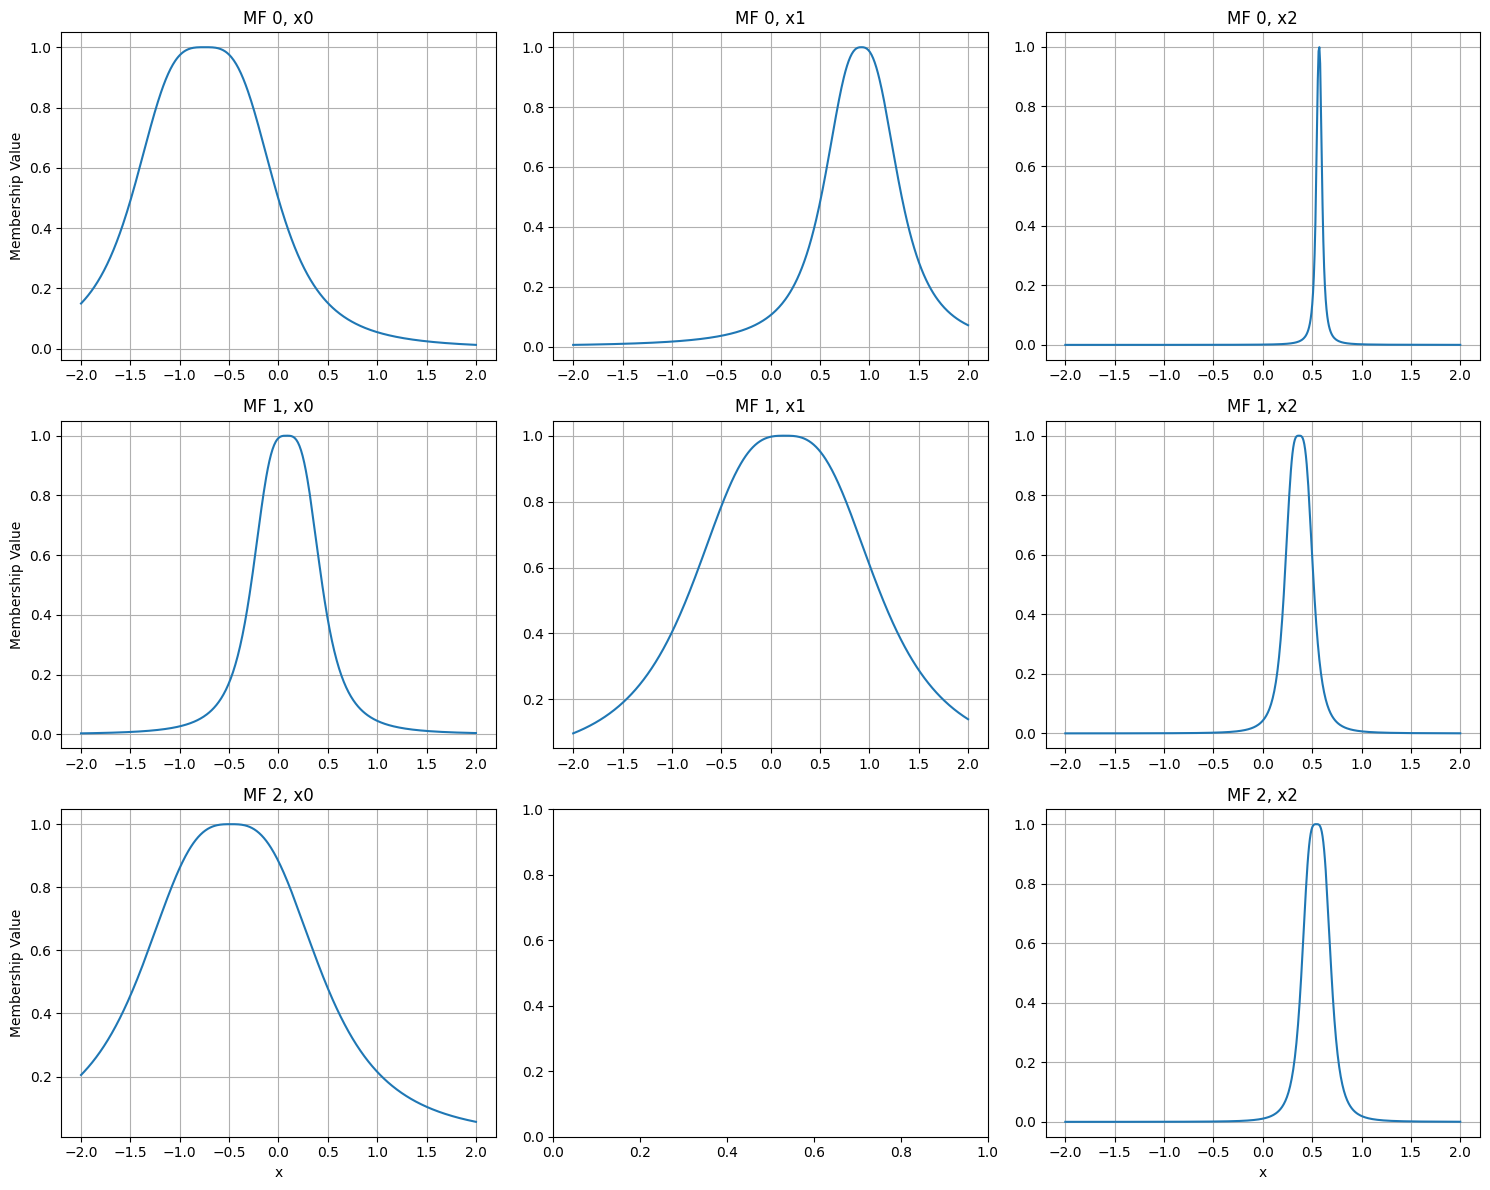

In [5]:
model.plot_premises()

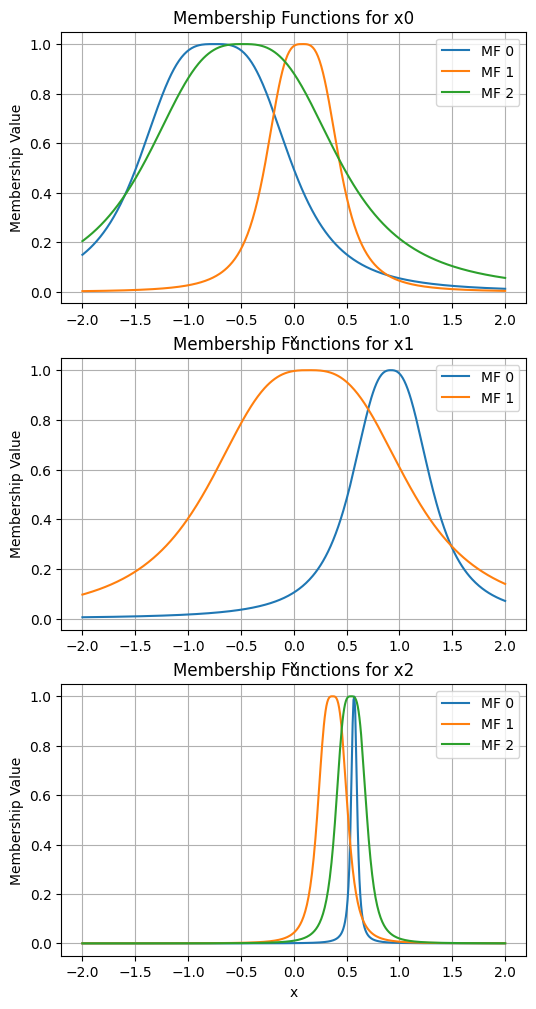

In [6]:
model.plot_premises(group_by_dim=True)

In [7]:
model.init_premises(x_train)

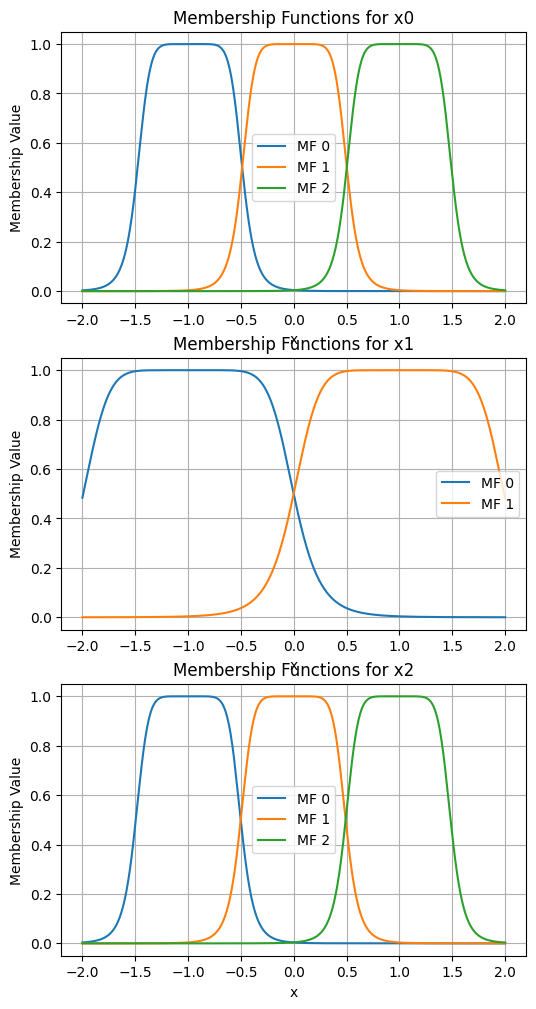

In [8]:
model.plot_premises(group_by_dim=True)

In [9]:
model.show_premises_structure()

        a (x0)  b (x0)    c (x0)    a (x1)  b (x1)    c (x1)    a (x2)  \
MF 0  0.494907     4.0 -0.982804  0.995618     4.0 -0.996472  0.496492   
MF 1  0.494907     4.0  0.007009  0.995618     4.0  0.994763  0.496492   
MF 2  0.494907     4.0  0.996822       NaN     NaN       NaN  0.496492   

      b (x2)    c (x2)  
MF 0     4.0 -0.998299  
MF 1     4.0 -0.005314  
MF 2     4.0  0.987670  


In [10]:
model.premises_structure

,a (x0),b (x0),c (x0),a (x1),b (x1),c (x1),a (x2),b (x2),c (x2)
MF 0,0.494907,4.0,-0.982804,0.995618,4.0,-0.996472,0.496492,4.0,-0.998299
MF 1,0.494907,4.0,0.007009,0.995618,4.0,0.994763,0.496492,4.0,-0.005314
MF 2,0.494907,4.0,0.996822,NaN,NaN,NaN,0.496492,4.0,0.987670


In [11]:
model.get_premises()

[tensor([[ 0.4949,  4.0000, -0.9828],
         [ 0.4949,  4.0000,  0.0070],
         [ 0.4949,  4.0000,  0.9968]]),
 tensor([[ 0.9956,  4.0000, -0.9965],
         [ 0.9956,  4.0000,  0.9948]]),
 tensor([[ 0.4965,  4.0000, -0.9983],
         [ 0.4965,  4.0000, -0.0053],
         [ 0.4965,  4.0000,  0.9877]])]

## Binary output

In [12]:
x_train = 2 * torch.rand(200, 3) - 1

In [13]:
x_train[:10]

tensor([[-0.6793, -0.6692,  0.1807],
        [ 0.7471, -0.9655, -0.8667],
        [-0.8654,  0.7458, -0.7448],
        [-0.9065, -0.0993,  0.1224],
        [ 0.7740,  0.3611,  0.3173],
        [ 0.9075, -0.0472,  0.2720],
        [-0.3695, -0.2158, -0.1924],
        [-0.3630, -0.9385,  0.6950],
        [-0.5952, -0.5350, -0.7547],
        [-0.5610, -0.5701, -0.9251]])

In [14]:
mf_distribution

[3, 2, 3]

In [15]:
bin_model = ANFIS(
    mf_distribution=mf_distribution, # Distribución de las funciones de membresía a lo largo de los features
    output_type='binary', # Tipo de salida: clasificación binaria
)

In [16]:
bin_model.get_premises()

[tensor([[0.7628, 1.3699, 0.2508],
         [0.4271, 1.0163, 0.1625],
         [0.3301, 1.4174, 0.5671]]),
 tensor([[ 0.2611,  1.7501,  0.6790],
         [ 0.3620,  1.3287, -0.6298]]),
 tensor([[0.3427, 1.1295, 0.9459],
         [0.5281, 1.5548, 0.1501],
         [0.1910, 1.9640, 0.2879]])]

In [17]:
bin_model.get_consequents()

tensor([[[-0.6029,  0.4113,  0.9076,  0.8421],
         [ 0.9258,  0.9184,  0.1114, -0.6302],
         [-0.5309,  0.2880,  0.9540,  0.3138],
         [-0.8394, -0.5394, -0.1270, -0.1877],
         [ 0.5760, -0.5207, -0.5291,  0.6961],
         [-0.0189, -0.5914,  0.8448,  0.9849],
         [ 0.8503, -0.8778,  0.0502,  0.4165],
         [ 0.0722,  0.5270,  0.5439,  0.4094],
         [-0.9696,  0.6708, -0.7432, -0.5783],
         [ 0.6410,  0.1988,  0.8346, -0.1985],
         [ 0.1542, -0.5167,  0.5160, -0.9430],
         [-0.1054, -0.0663,  0.7582,  0.6410],
         [-0.6742,  0.9695, -0.9411,  0.6832],
         [-0.0491,  0.5709, -0.1776,  0.9569],
         [ 0.7839, -0.7709,  0.0677,  0.2285],
         [-0.0065, -0.1694, -0.6538, -0.1684],
         [-0.9342,  0.0672, -0.5553, -0.5606],
         [ 0.2134, -0.1124,  0.0020,  0.9996]]])

In [20]:
bin_model(x_train[:10])

tensor([0.6582, 0.5680, 0.4394, 0.5558, 0.6047, 0.5961, 0.5114, 0.5837, 0.5545,
        0.5618], grad_fn=<SigmoidBackward0>)

In [21]:
bin_model.predict(x_train[:10])

array([1, 1, 0, 1, 1, 1, 1, 1, 1, 1])

## Multiclass output

In [32]:
x_train = 2 * torch.rand(200, 3) - 1

In [33]:
mul_class_model = ANFIS(
    mf_distribution=mf_distribution, # Distribución de las funciones de membresía a lo largo de los features
    outputs=3, # 3 clases
    output_type='multiclass', # Tipo de salida: clasificación multiclase
)

In [34]:
mul_class_model(x_train[:10])

tensor([[ 0.0307,  0.2805,  0.2558],
        [ 0.1029, -0.0219,  0.3365],
        [-0.1156,  0.2894,  0.3657],
        [ 0.3065,  0.1498,  0.0498],
        [ 0.3051, -0.0133,  0.3439],
        [ 0.0618,  0.1224,  0.0748],
        [ 0.7534,  0.1007,  0.0843],
        [-0.1371,  0.0147,  0.0977],
        [-0.5956, -0.0822,  0.0667],
        [ 0.4173,  0.2276, -0.0357]], grad_fn=<SqueezeBackward1>)

In [35]:
mul_class_model(x_train[:10], return_probabilities=True)

tensor([[0.2828, 0.3630, 0.3542],
        [0.3179, 0.2806, 0.4015],
        [0.2429, 0.3641, 0.3930],
        [0.3804, 0.3253, 0.2943],
        [0.3614, 0.2629, 0.3757],
        [0.3251, 0.3454, 0.3294],
        [0.4919, 0.2561, 0.2520],
        [0.2917, 0.3395, 0.3688],
        [0.2169, 0.3624, 0.4206],
        [0.4060, 0.3359, 0.2581]], grad_fn=<SoftmaxBackward0>)

In [36]:
mul_class_model.predict(x_train[:10])

array([1, 2, 2, 0, 2, 1, 0, 2, 2, 0])